### **[Nonlinear Feature Extraction for Financial Time Series Prediction Using Causal Legendre Polynomials](https://medium.com/@alexzap922/62089ca09218)**

> *Building a Complete Python Pipeline with Legendre Polynomials without Lookahead Bias*

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

IN_COLAB = 'google.colab' in sys.modules

from numpy.polynomial.legendre import legfit, legval
from numpy.polynomial.legendre import Legendre

import yfinance as yf

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)

#### **Legendre Polynomials**

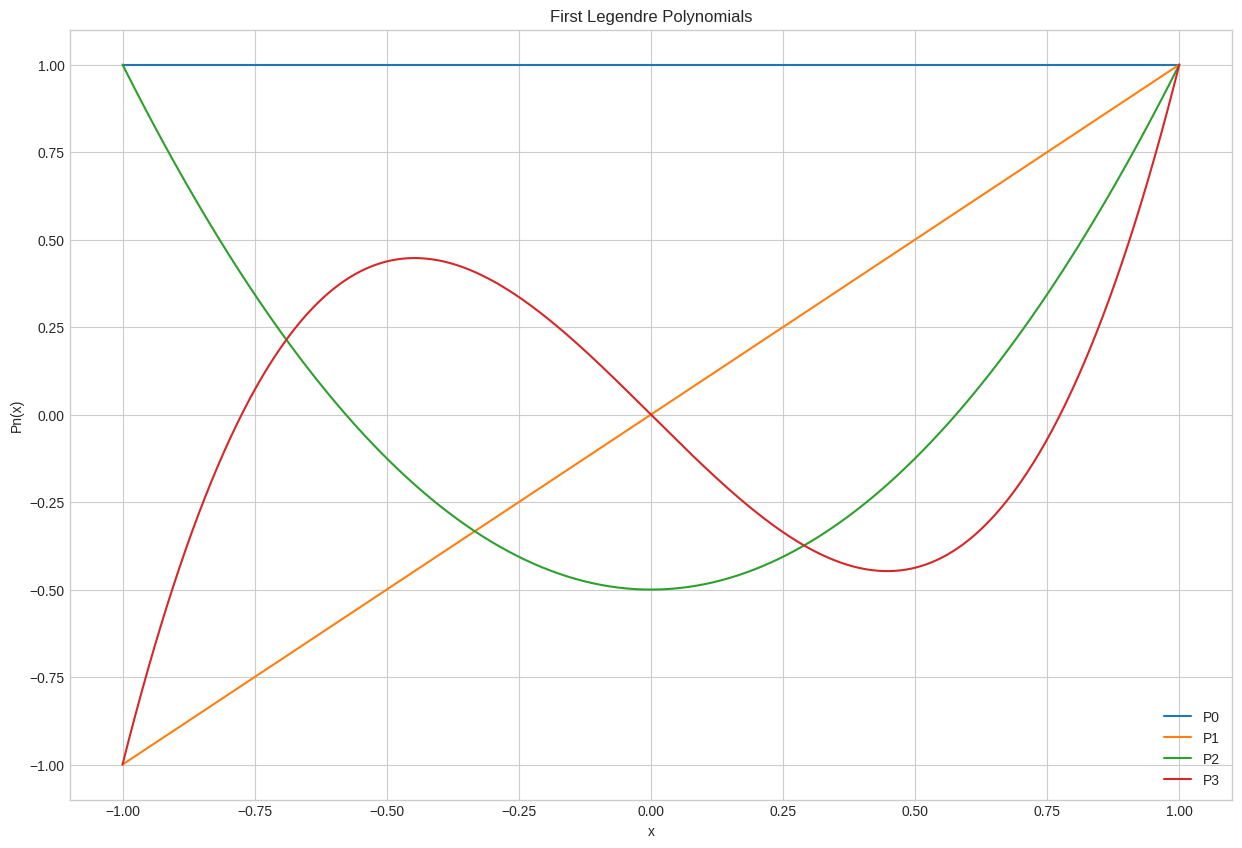

In [2]:
# x values
x = np.linspace(-1, 1, 500)

# first Legendre polynomials
P0 = np.ones_like(x)
P1 = x
P2 = 0.5 * (3*x**2 - 1)
P3 = 0.5 * (5*x**3 - 3*x)

# plot
plt.plot(x, P0, label='P0')
plt.plot(x, P1, label='P1')
plt.plot(x, P2, label='P2')
plt.plot(x, P3, label='P3')

plt.legend()
plt.grid(True)
plt.title("First Legendre Polynomials")
plt.xlabel("x")
plt.ylabel("Pn(x)")
plt.show()

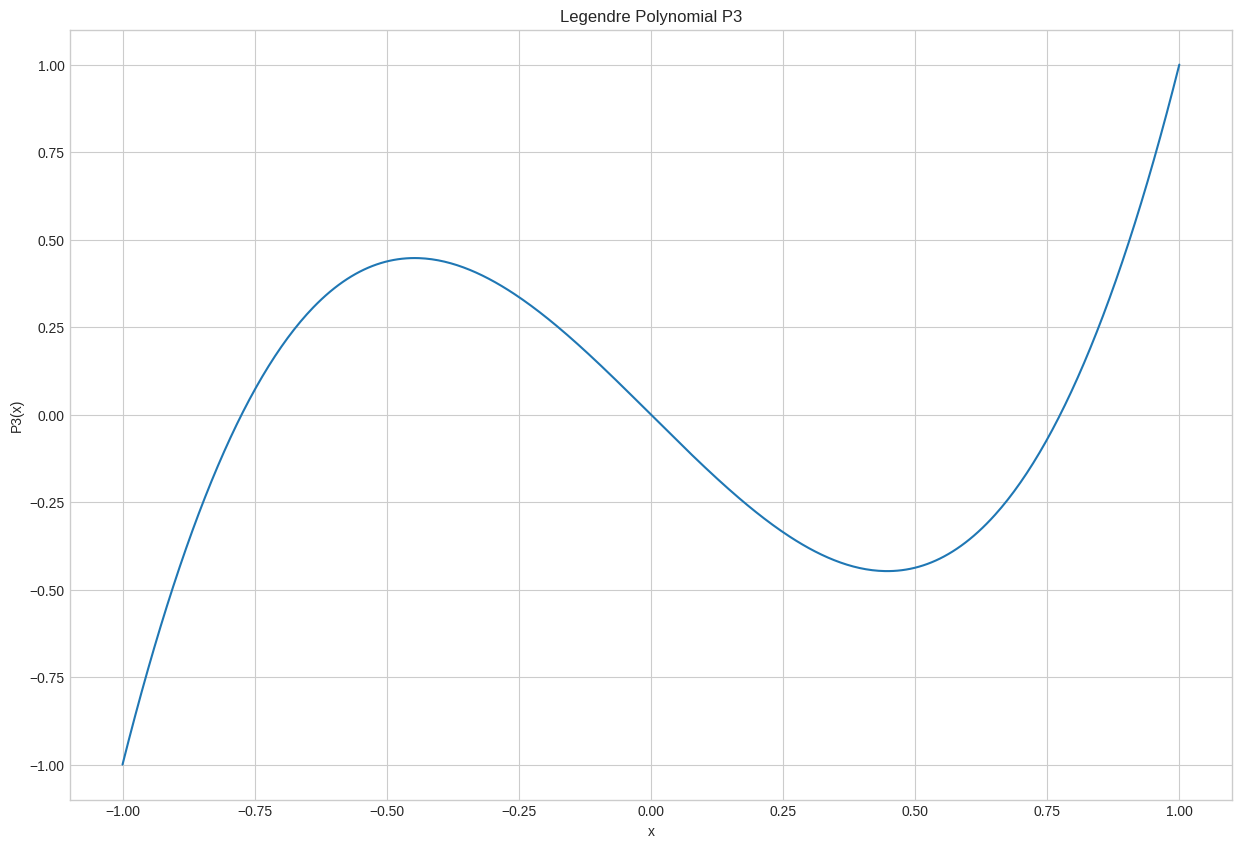

In [3]:
x = np.linspace(-1, 1, 500)

# P3
P3 = Legendre.basis(3)

plt.plot(x, P3(x))
plt.grid(True)
plt.title("Legendre Polynomial P3")
plt.xlabel("x")
plt.ylabel("P3(x)")
plt.show()

#### **Legendre Transform**

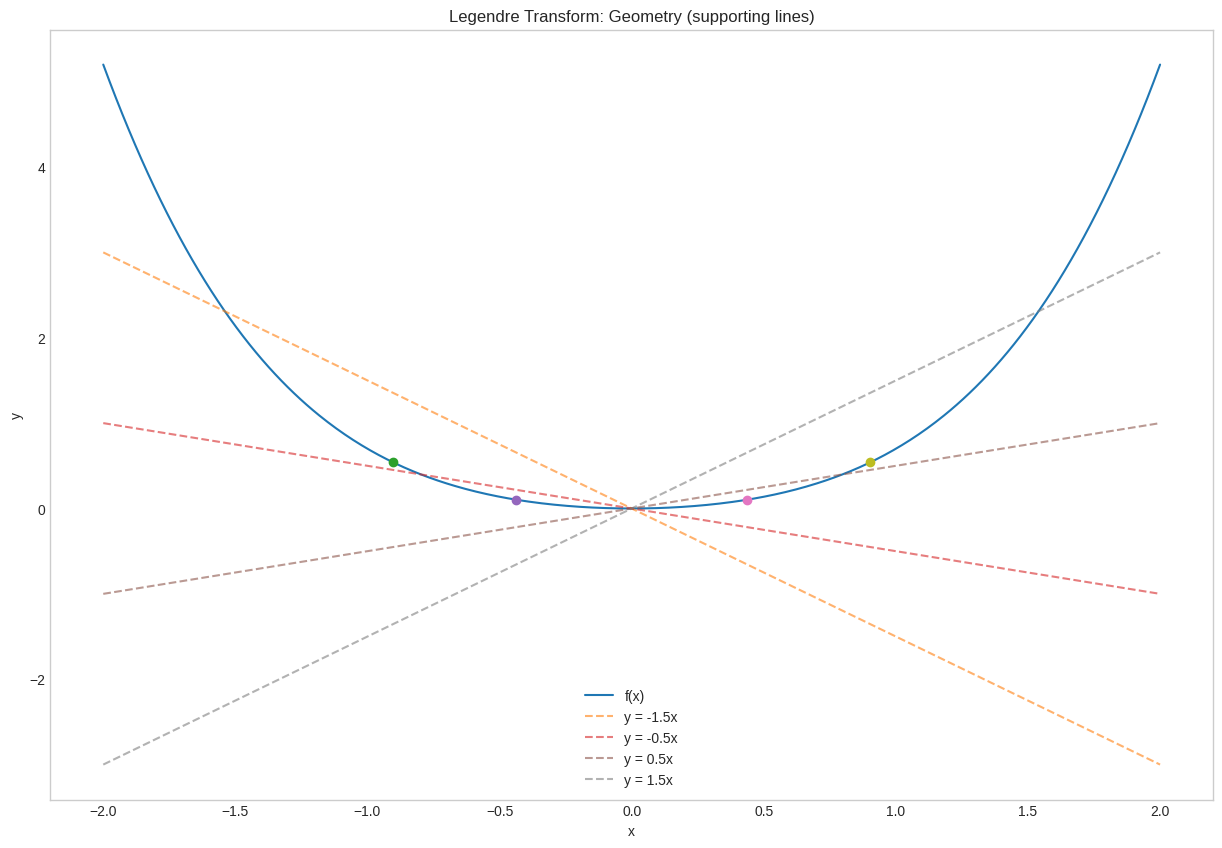

In [4]:
# Choose a smooth bowl-shaped curve (convex).
def f(x):
  return 0.5 * x**2 + 0.2 * x**4   # convex example

# The derivative tells us the slope of the curve at each point.
def df(x):
  return x + 0.8 * x**3
#This derivative is not actually used below.
#It’s included for completeness.

# grid for x
x = np.linspace(-2, 2, 500)

# choose several p values (slopes)
p_values = [-1.5, -0.5, 0.5, 1.5]

# --- Plot f(x) ---
plt.figure(figsize=(15, 10))
plt.plot(x, f(x), label="f(x)")

for p in p_values:
  # supporting line y = p x
  plt.plot(x, p * x, linestyle="--", alpha=0.6, label=f"y = {p}x")

  # numerical maximization of F(p,x)
  F = p * x - f(x)
  x_star = x[np.argmax(F)]
  y_star = f(x_star)

  plt.plot(x_star, y_star, 'o')

plt.title("Legendre Transform: Geometry (supporting lines)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid()

plt.show()

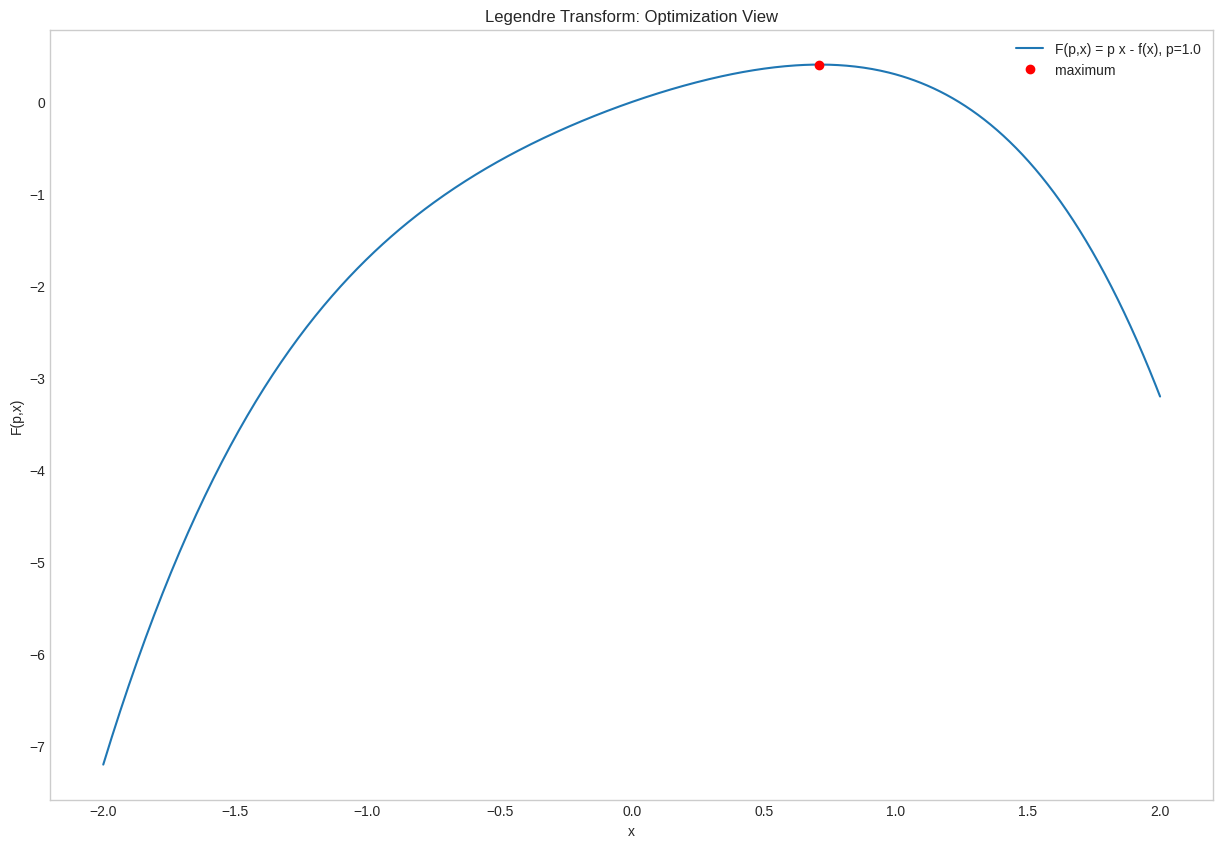

In [5]:
# --- Plot F(p,x) = px - f(x) for one p ---
p = 1.0
F = p * x - f(x)

x_star = x[np.argmax(F)]
g_p = np.max(F)

plt.figure(figsize=(15, 10))
plt.plot(x, F, label=f"F(p,x) = p x - f(x), p={p}")
plt.plot(x_star, g_p, 'ro', label="maximum")

plt.title("Legendre Transform: Optimization View")
plt.xlabel("x")
plt.ylabel("F(p,x)")
plt.legend()
plt.grid()

plt.show()

#### **Legendre Transform in Portfolio Optimization**

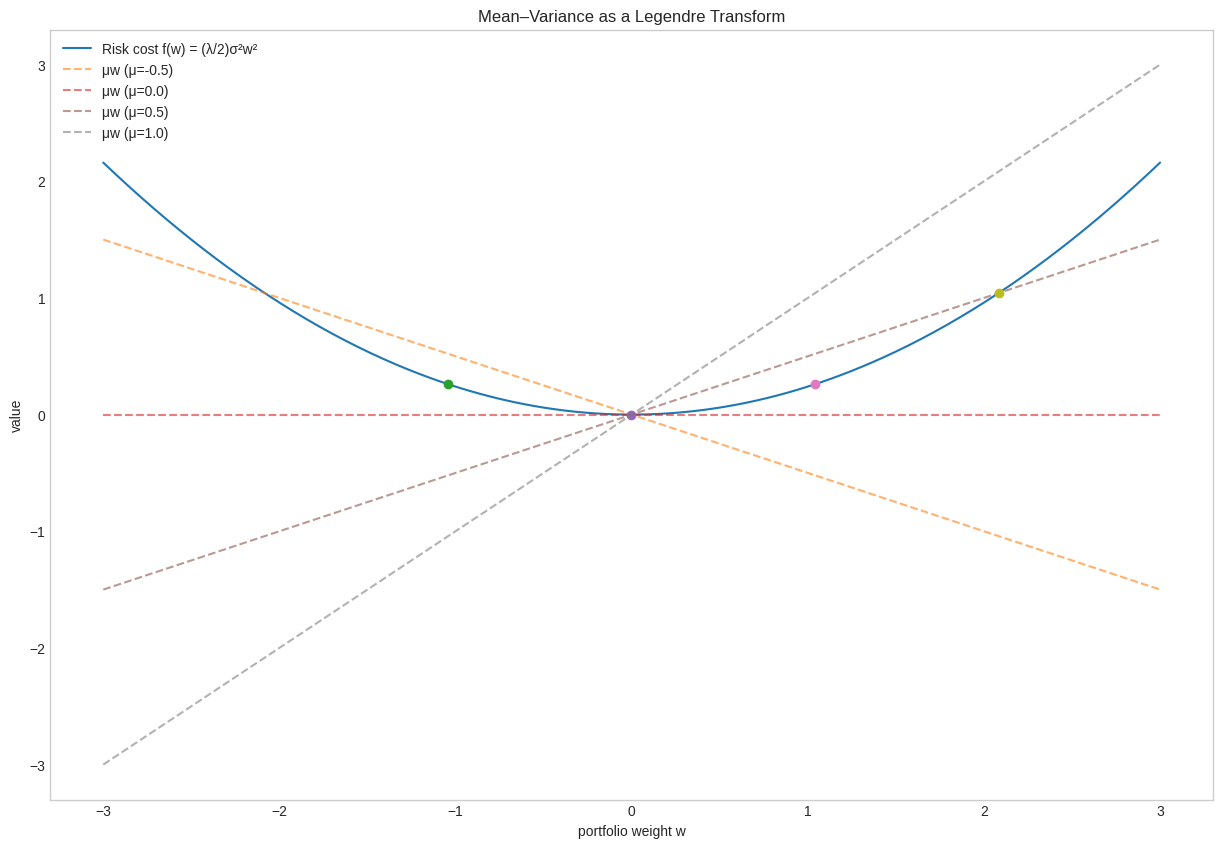

In [6]:
# -----------------------------
# Mean–variance risk function
# f(w) = (λ/2) σ² w²
# -----------------------------
sigma = 0.4
lam = 3.0

def f(w):
  return 0.5 * lam * sigma**2 * w**2

def df(w):
  return lam * sigma**2 * w  # not used, but conceptually slope

# -----------------------------
# grid for portfolio weights
# -----------------------------
w = np.linspace(-3, 3, 500)

# expected returns (acts like slope p)
mu_values = [-0.5, 0.0, 0.5, 1.0]

# -----------------------------
# Plot risk function + linear reward
# -----------------------------
plt.figure(figsize=(15, 10))
plt.plot(w, f(w), label="Risk cost f(w) = (λ/2)σ²w²")

for mu in mu_values:
  # linear reward term μw
  plt.plot(w, mu * w, linestyle="--", alpha=0.6, label=f"μw (μ={mu})")

  # Legendre-style objective
  F = mu * w - f(w)

  w_star = w[np.argmax(F)]
  f_star = f(w_star)

  plt.plot(w_star, f_star, 'o')

plt.title("Mean–Variance as a Legendre Transform")
plt.xlabel("portfolio weight w")
plt.ylabel("value")
plt.legend()
plt.grid()
plt.show()

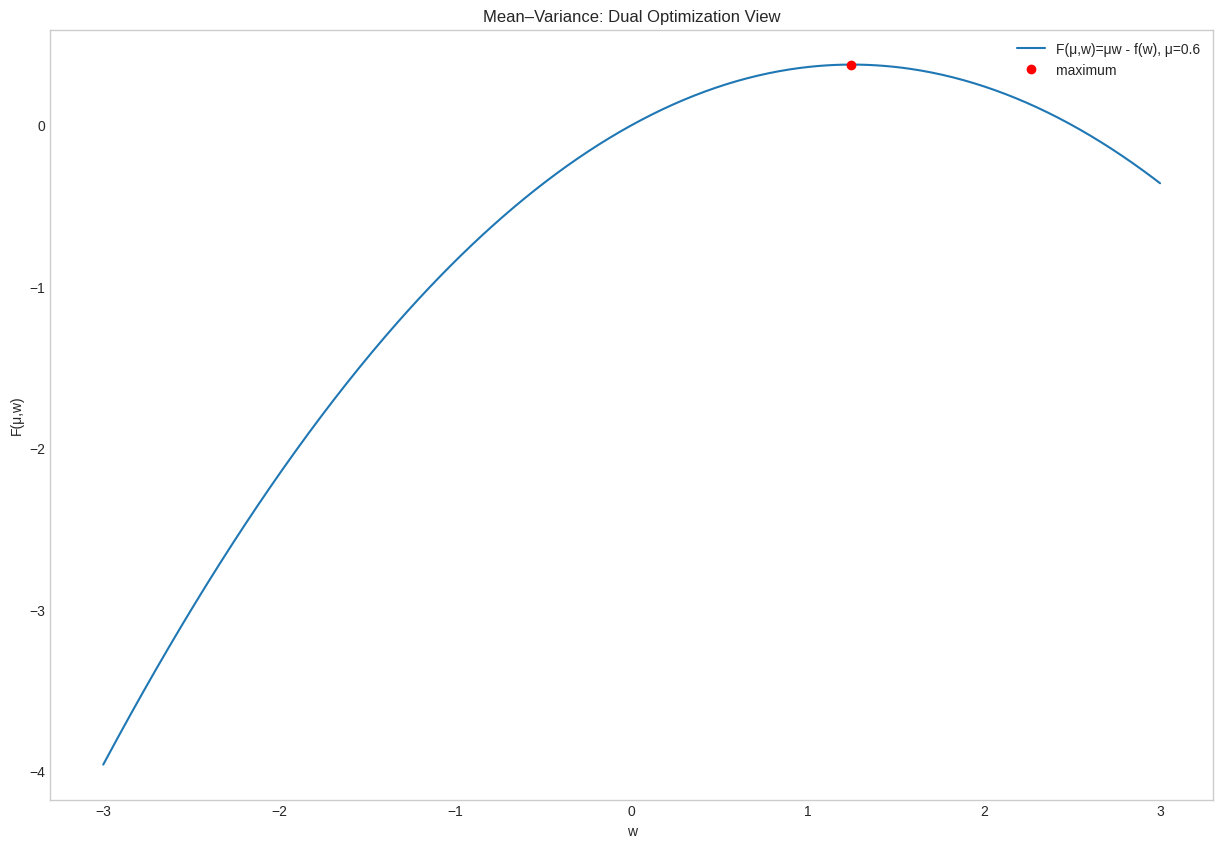

In [7]:
# -----------------------------
# Dual function F(μ) = max_w (μw - f(w))
# -----------------------------
mu = 0.6
F = mu * w - f(w)

w_star = w[np.argmax(F)]
g_mu = np.max(F)

plt.figure(figsize=(15, 10))
plt.plot(w, F, label=f"F(μ,w)=μw - f(w), μ={mu}")
plt.plot(w_star, g_mu, 'ro', label="maximum")

plt.title("Mean–Variance: Dual Optimization View")
plt.xlabel("w")
plt.ylabel("F(μ,w)")
plt.legend()
plt.grid()

plt.show()

#### **Legendre Polynomial Expansion of Time Series**

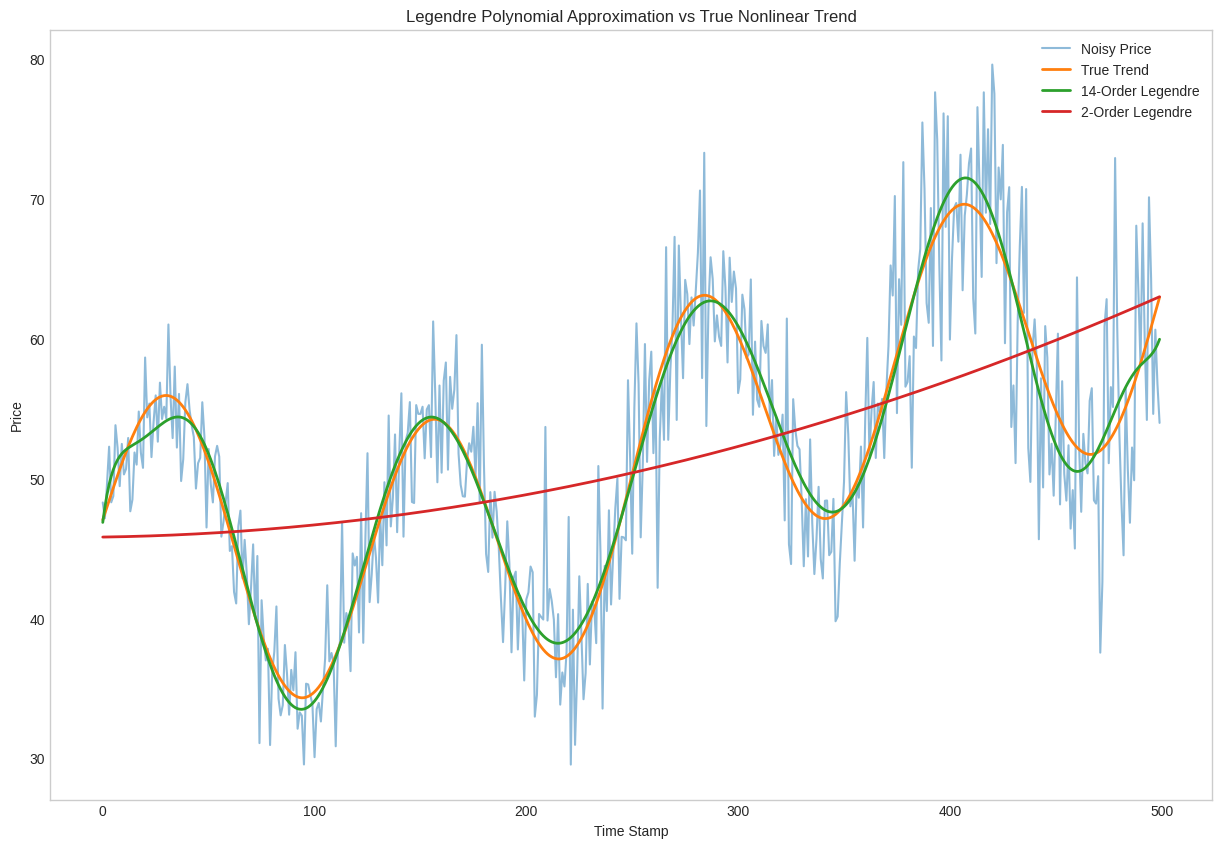

In [8]:
# =========================
# SYNTHETIC DATA
# =========================
N = 500
t = np.arange(N)
u = -1 + 2 * t / (N - 1) #generate 500 time points and rescale them to the interval [-1,1].

#Build the “true” nonlinear trend
true_trend = (
  50
  + 10 * np.sin(2 * np.pi * u * 2)
  + 5 * u**2
  + 8 * np.tanh(3 * u)
)
#Add heteroskedastic noise
volatility = 2.5 + 4 * (u + 1) / 2
noise = volatility * np.random.randn(N)
#This mimics financial data where variance changes over time.
price = true_trend + noise

# =========================
# LEGENDRE APPROXIMATION
# =========================
degree = 14  # high-order approximation

coeffs = legfit(u, price, deg=degree)
approx_trend = legval(u, coeffs) #This evaluates the fitted polynomial expansion.

# =========================
# OPTIONAL: SMOOTH TREND ONLY (LOW FREQUENCIES)
# =========================
low_degree = 2
coeffs_low = legfit(u, price, deg=low_degree)
smooth_trend = legval(u, coeffs_low) #captures only the broad macro shape.
#This is essentially a low frequency compression of the signal.

# =========================
# PLOT
# =========================
plt.figure(figsize=(15, 10))

plt.plot(price, label="Noisy Price", alpha=0.5)
plt.plot(true_trend, label="True Trend", linewidth=2)
plt.plot(approx_trend, label="14-Order Legendre", linewidth=2)
plt.plot(smooth_trend, label="2-Order Legendre", linewidth=2)

plt.title("Legendre Polynomial Approximation vs True Nonlinear Trend")
plt.xlabel("Time Stamp")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

#### **Causal Legendre Polynomials in Time Series Analysis**

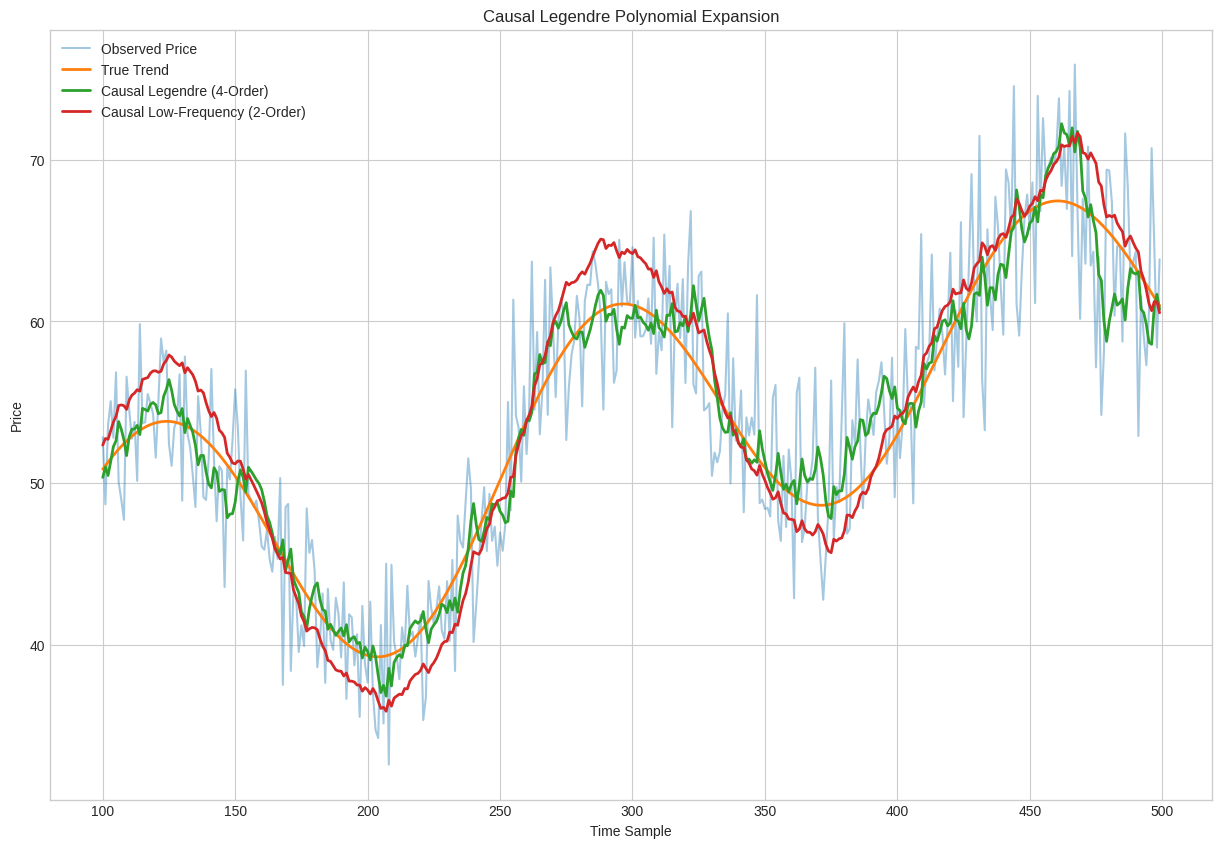

In [9]:
# =====================================================
# SYNTHETIC TIME SERIES
# =====================================================

N = 500
t = np.arange(N)

# normalize time to [-1, 1]
u = -1 + 2 * t / (N - 1)

# smooth latent signal
true_trend = (
  50
  + 8 * np.sin(2 * np.pi * u * 1.5)
  + 5 * u**2
  + 6 * np.tanh(3 * u)
)
'''
The latent signal combines:

a constant level
oscillatory structure (sin)
smooth curvature (u**2)
nonlinear saturation (tanh)

This produces a realistic nonlinear trend.
'''
# heteroskedastic noise
volatility = 2 + 3 * (u + 1) / 2
noise = volatility * np.random.randn(N)

#The volatility increases gradually over time.

#So the right side of the series becomes noisier than the left side.

# observed process
price = true_trend + noise

# =====================================================
# CAUSAL LEGENDRE ESTIMATION
# =====================================================

degree = 4
window = 100

causal_fit = np.full(N, np.nan)

for t_now in range(window, N):
  # ---------------------------------------------
  # ONLY USE PAST INFORMATION
  # ---------------------------------------------

  y_window = price[t_now - window:t_now]

  # local normalized coordinates
  local_x = np.linspace(-1, 1, window)

  # fit Legendre polynomial using ONLY past data
  coeffs = legfit(local_x, y_window, deg=degree)

  # estimate current endpoint
  # x=1 corresponds to "now"
  causal_fit[t_now] = legval(1, coeffs)

# =====================================================
# LOW-FREQUENCY CAUSAL FILTER
# =====================================================

low_degree = 2
smooth_fit = np.full(N, np.nan)

for t_now in range(window, N):
  y_window = price[t_now - window:t_now]
  local_x = np.linspace(-1, 1, window)

  coeffs_low = legfit(local_x, y_window, deg=low_degree)

  smooth_fit[t_now] = legval(1, coeffs_low)

plot_start = window

# =====================================================
# PLOT
# =====================================================

plt.figure(figsize=(15, 10))

plt.plot(
  t[plot_start:],
  price[plot_start:],
  alpha=0.4,
  label="Observed Price"
)

plt.plot(
  t[plot_start:],
  true_trend[plot_start:],
  linewidth=2,
  label="True Trend"
)

plt.plot(
  t[plot_start:],
  causal_fit[plot_start:],
  linewidth=2,
  label=f"Causal Legendre ({degree}-Order)"
)

plt.plot(
  t[plot_start:],
  smooth_fit[plot_start:],
  linewidth=2,
  label=f"Causal Low-Frequency ({low_degree}-Order)"
)

plt.title("Causal Legendre Polynomial Expansion")
plt.xlabel("Time Sample")
plt.ylabel("Price")

plt.legend()
plt.grid(True)

plt.show()

#### **Legendre Trend Filtering on Stock Closing Prices**

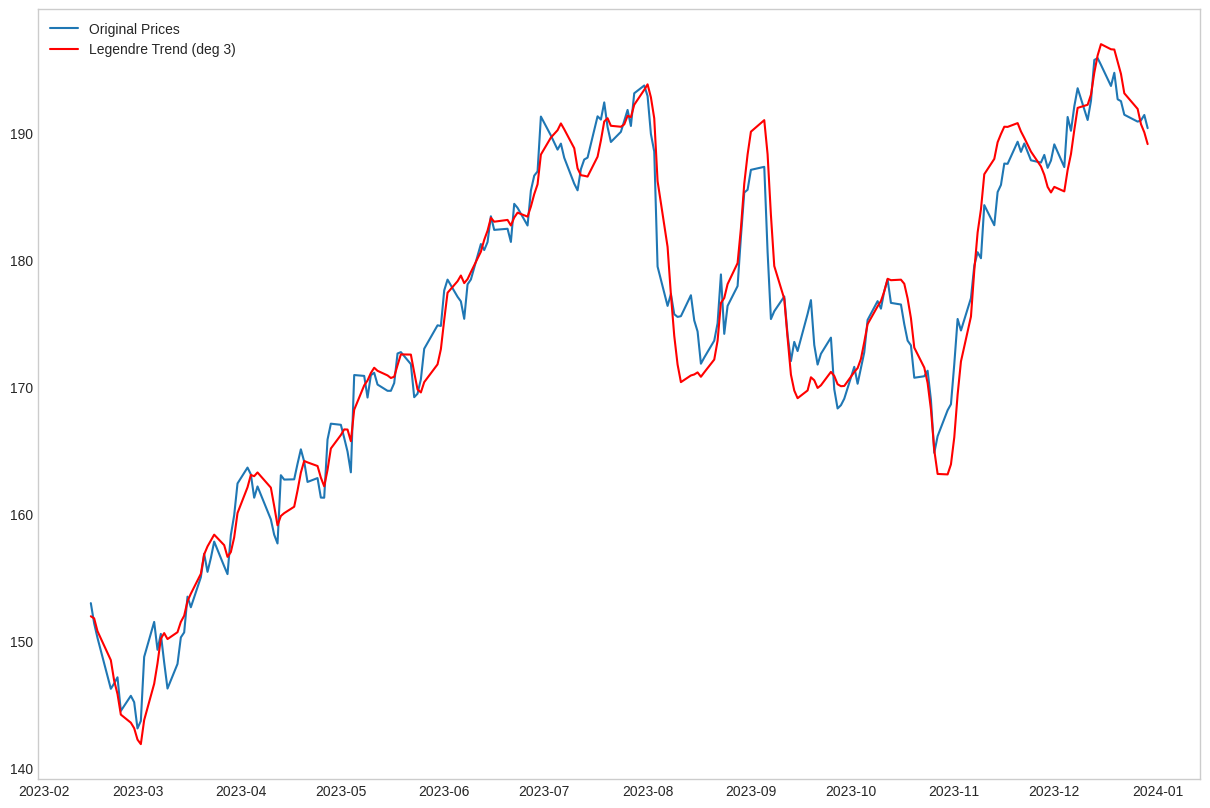

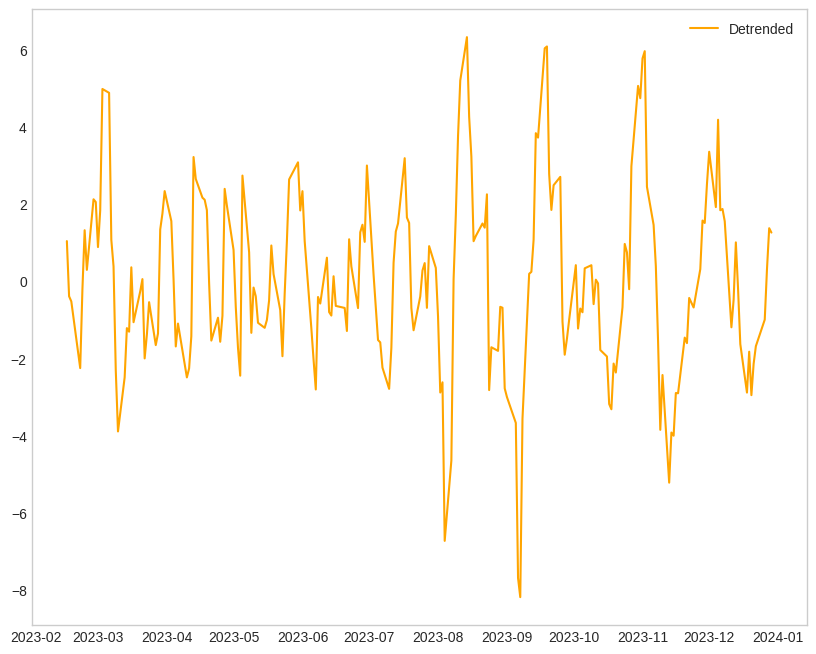

In [10]:
# Download stock data
ticker = "AAPL"
data = yf.download(ticker, start="2023-01-01", end="2024-01-01", progress=False, multi_level_index=False)

# Extract closing prices and flatten
prices = data["Close"].to_numpy().flatten()  # now shape (n,)
n = len(prices)
t = np.arange(n)

# Map time to [-1,1]
x = -1 + 2 * t / (n - 1)

trend = np.zeros_like(prices)
window = 30  # only use past 30 days

for i in range(window-1, len(prices)):
  x_window = np.linspace(-1, 1, window)  # scale past points to [-1,1]
  y_window = prices[i-window+1:i+1]
  coeffs = np.polynomial.legendre.legfit(x_window, y_window, deg=3)
  trend[i] = np.polynomial.legendre.legval(1, coeffs)  # value at most recent point

# Detrended / filtered series
detrended = prices - trend
deg = 3
# Plot
plt.figure(figsize=(15, 10))
plt.plot(data.index[30:], prices[30:], label="Original Prices")
plt.plot(data.index[30:], trend[30:], label=f"Legendre Trend (deg {deg})", color="red")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 8))
plt.plot(data.index[30:], detrended[30:], label="Detrended", color="orange")
plt.legend()
plt.grid()
plt.show()

#### **Causal Legendre Crossover Trading Strategy**

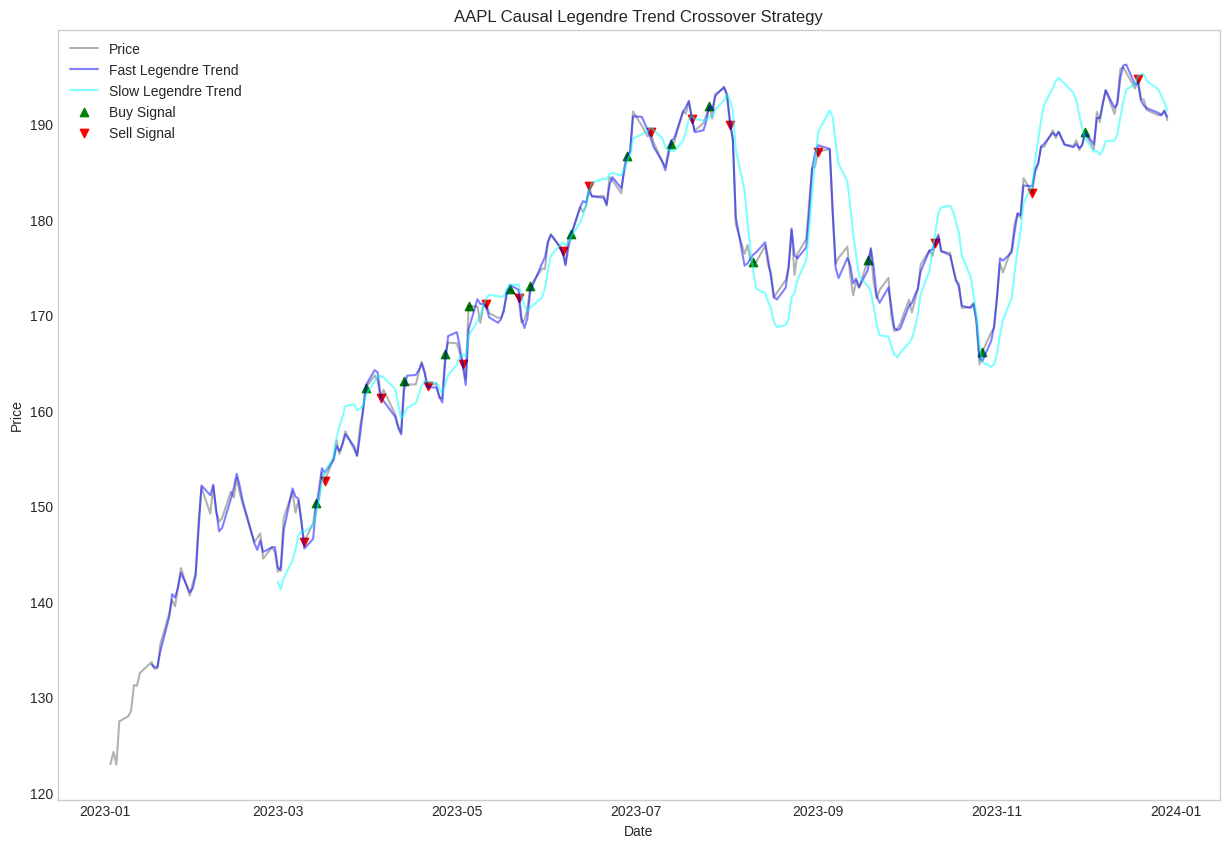

In [11]:
# --- Load stock data ---
ticker = "AAPL"
data = yf.download(ticker, start="2023-01-01", end="2024-01-01", progress=False, multi_level_index=False)
prices = data["Close"].to_numpy().flatten()
n = len(prices)

# --- Parameters ---
window_fast = 10   # fast Legendre trend
window_slow = 40   # slow Legendre trend
deg = 3            # polynomial degree

# --- Allocate arrays ---
trend_fast = np.full(n, np.nan)
trend_slow = np.full(n, np.nan)

# --- Causal Legendre trends ---
def causal_legendre(prices, window, deg):
    n = len(prices)
    trend = np.full(n, np.nan)
    for i in range(window-1, n):
        y_win = prices[i-window+1:i+1]
        x_win = np.linspace(-1, 1, window)
        coeffs = legfit(x_win, y_win, deg)
        trend[i] = legval(1, coeffs)  # evaluate at most recent point
    return trend

trend_fast = causal_legendre(prices, window_fast, deg)
trend_slow = causal_legendre(prices, window_slow, deg)

# --- Generate crossover signals ---
# 1 = buy, -1 = sell, 0 = hold
signal = np.zeros(n)
for i in range(1, n):
  if np.isnan(trend_fast[i-1]) or np.isnan(trend_slow[i-1]):
    continue
  if trend_fast[i-1] < trend_slow[i-1] and trend_fast[i] > trend_slow[i]:
    signal[i] = 1  # buy
  elif trend_fast[i-1] > trend_slow[i-1] and trend_fast[i] < trend_slow[i]:
    signal[i] = -1  # sell

# --- Plot results ---
plt.figure(figsize=(15, 10))
plt.plot(data.index, prices, label="Price", color="black",alpha=0.3)
plt.plot(data.index, trend_fast, label="Fast Legendre Trend", color="blue",alpha=0.5)
plt.plot(data.index, trend_slow, label="Slow Legendre Trend", color="cyan",alpha=0.5)
plt.scatter(data.index[signal==1], prices[signal==1], marker="^", color="green", label="Buy Signal")
plt.scatter(data.index[signal==-1], prices[signal==-1], marker="v", color="red", label="Sell Signal")
plt.title(f"{ticker} Causal Legendre Trend Crossover Strategy")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.legend()
plt.show()

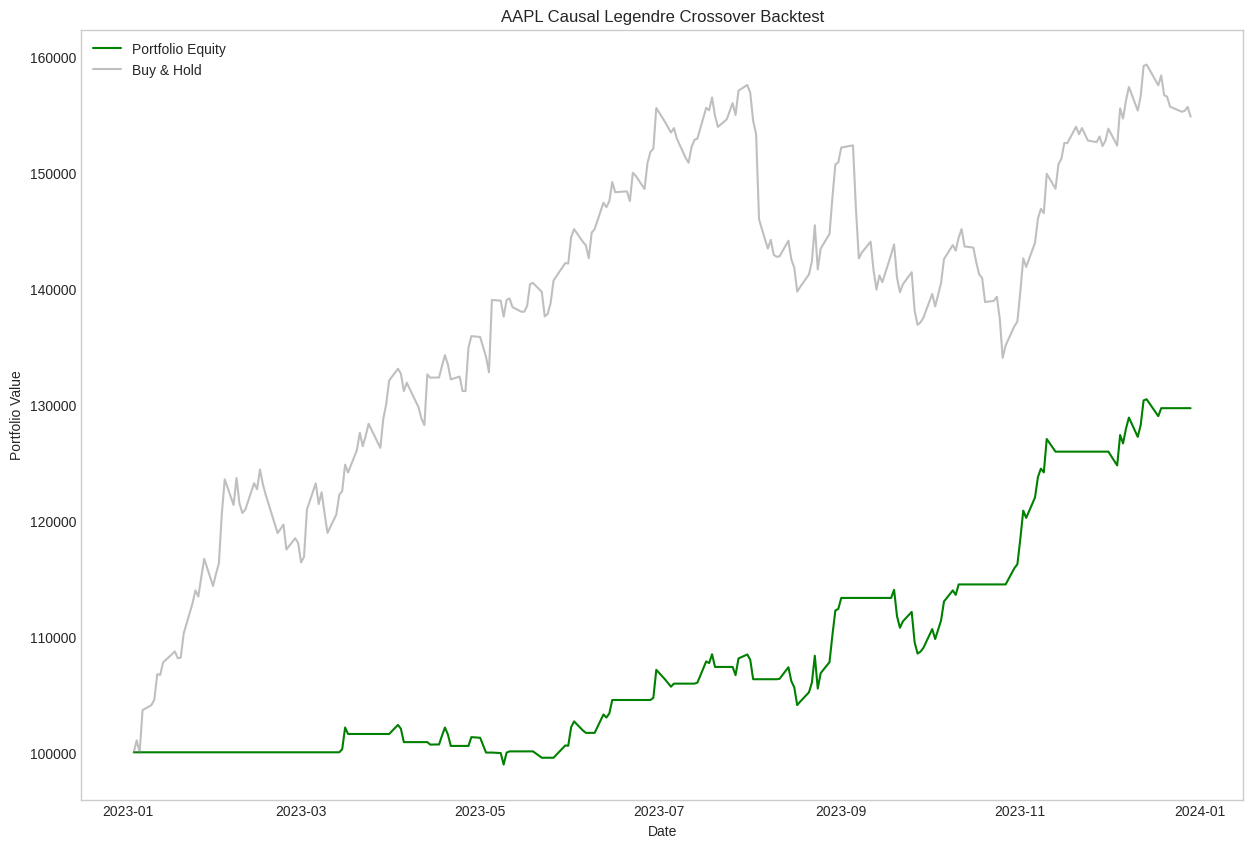

Final equity: $129664.91
Buy & Hold final value: $154798.24


In [12]:
# --- Backtest ---
position = 0         # current position (0 = no position, 1 = long)
cash = 100000        # starting cash
equity = np.zeros(n) # portfolio value
shares = 0

for i in range(n):
  price = prices[i]
  if signal[i] == 1 and position == 0:  # buy
    shares = cash // price
    cash -= shares * price
    position = 1
  elif signal[i] == -1 and position == 1:  # sell
    cash += shares * price
    shares = 0
    position = 0
  equity[i] = cash + shares * price

# --- Plot equity curve ---
plt.figure(figsize=(15, 10))
plt.plot(data.index, equity, label="Portfolio Equity", color="green")
plt.plot(data.index, prices / prices[0] * 100000, label="Buy & Hold", color="gray", alpha=0.5)
plt.title(f"{ticker} Causal Legendre Crossover Backtest")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid()
plt.show()

# --- Print final results ---
print(f"Final equity: ${equity[-1]:.2f}")
print(f"Buy & Hold final value: ${prices[-1]/prices[0]*100000:.2f}")

#### **Sharpe-Optimized Causal Legendre Crossover Trading Signals**

In [13]:
# --- Load stock data ---
ticker = "AAPL"
data = yf.download(ticker, start="2020-01-01", end="2026-05-21", progress=False, multi_level_index=False)
prices = data["Close"].to_numpy().flatten()
n = len(prices)

# --- Parameters ---
deg = 3
fast_range = range(5, 30, 2)
slow_range = range(20, 70, 2)

# --- Causal Legendre trend ---
def causal_legendre(prices, window, deg):
    n = len(prices)
    trend = np.full(n, np.nan)
    for i in range(window-1, n):
        y_win = prices[i-window+1:i+1]
        x_win = np.linspace(-1, 1, window)
        coeffs = legfit(x_win, y_win, deg)
        trend[i] = legval(1, coeffs)
    return trend

# --- Backtest function to get Sharpe ---
def backtest_sharpe(prices, fast_window, slow_window, deg):
  trend_fast = causal_legendre(prices, fast_window, deg)
  trend_slow = causal_legendre(prices, slow_window, deg)
  signal = np.zeros(n)
  for i in range(1, n):
    if np.isnan(trend_fast[i-1]) or np.isnan(trend_slow[i-1]):
      continue
    if trend_fast[i-1] < trend_slow[i-1] and trend_fast[i] > trend_slow[i]:
      signal[i] = 1
    elif trend_fast[i-1] > trend_slow[i-1] and trend_fast[i] < trend_slow[i]:
      signal[i] = -1

  # Backtest equity
  position = 0
  cash = 100000
  equity = np.zeros(n)
  shares = 0
  for i in range(n):
    price = prices[i]
    if signal[i] == 1 and position == 0:
      shares = cash // price
      cash -= shares * price
      position = 1
    elif signal[i] == -1 and position == 1:
      cash += shares * price
      shares = 0
      position = 0
    equity[i] = cash + shares * price
  returns = np.diff(equity) / equity[:-1]
  if np.std(returns) == 0:
    return -np.inf
  sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252)
  return sharpe

# --- Grid search ---
sharpe_grid = np.full((len(fast_range), len(slow_range)), np.nan)

for i, fast in enumerate(fast_range):
  for j, slow in enumerate(slow_range):
    if fast >= slow:
      continue
    sharpe_grid[i, j] = backtest_sharpe(prices, fast, slow, deg)

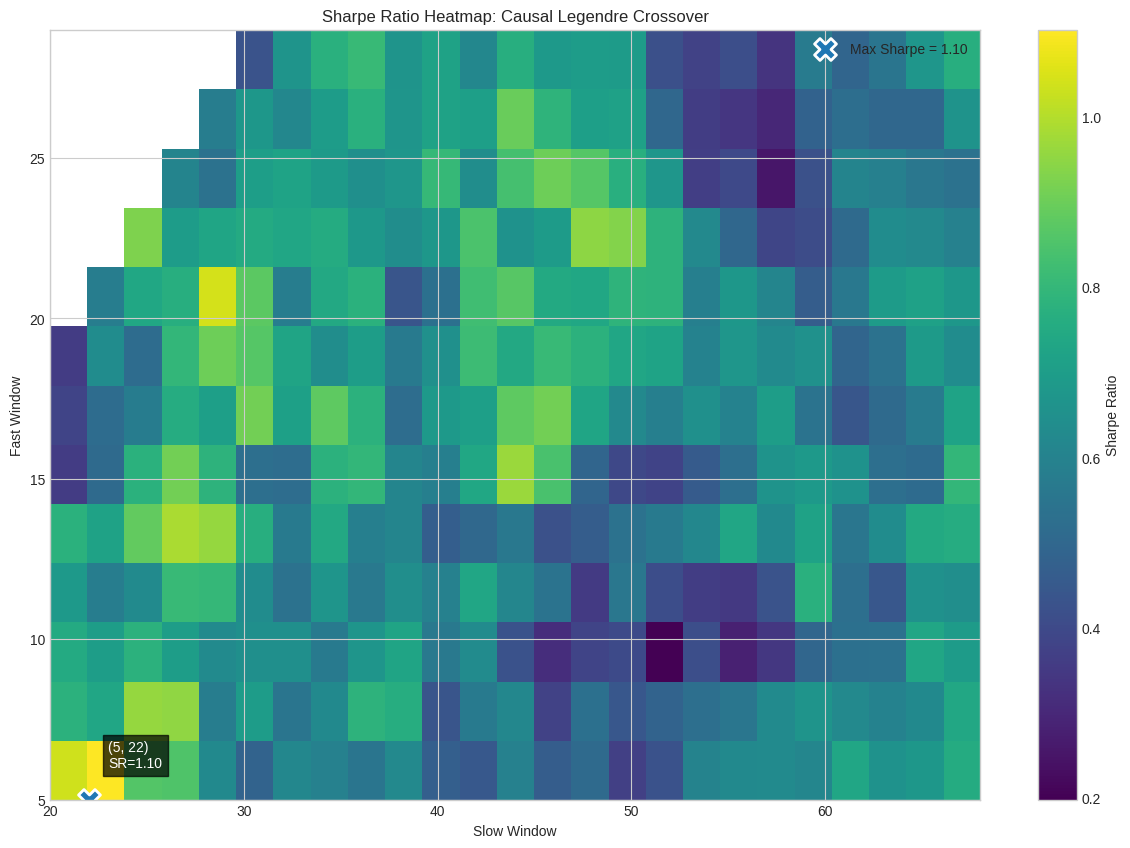

Best Fast Window: 5
Best Slow Window: 22
Best Sharpe Ratio: 1.10


In [14]:
# --- Find max Sharpe point ---
max_idx = np.nanargmax(sharpe_grid)
max_i, max_j = np.unravel_index(max_idx, sharpe_grid.shape)

best_fast = list(fast_range)[max_i]
best_slow = list(slow_range)[max_j]
best_sharpe = sharpe_grid[max_i, max_j]

# --- Plot Heatmap ---
plt.figure(figsize=(15, 10))

im = plt.imshow(
  sharpe_grid,
  origin='lower',
  aspect='auto',
  extent=[
    slow_range[0],
    slow_range[-1],
    fast_range[0],
    fast_range[-1]
  ],
  cmap='viridis'
)

plt.colorbar(im, label='Sharpe Ratio')

# --- Mark optimal point ---
plt.scatter(
  best_slow,
  best_fast,
  marker='X',
  s=250,
  edgecolors='white',
  linewidths=2,
  label=f'Max Sharpe = {best_sharpe:.2f}'
)

# --- Annotate point ---
plt.text(
  best_slow + 1,
  best_fast + 1,
  f'({best_fast}, {best_slow})\nSR={best_sharpe:.2f}',
  color='white',
  fontsize=10,
  bbox=dict(facecolor='black', alpha=0.7)
)

plt.xlabel('Slow Window')
plt.ylabel('Fast Window')
plt.title('Sharpe Ratio Heatmap: Causal Legendre Crossover')

plt.legend()
plt.show()

# --- Print best parameters ---
print(f"Best Fast Window: {best_fast}")
print(f"Best Slow Window: {best_slow}")
print(f"Best Sharpe Ratio: {best_sharpe:.2f}")

=== Causal Legendre Crossover ===
Total Return: 707.7%
CAGR: 38.7%
Max Drawdown: 25.2%
Sharpe Ratio: 0.87
Total Trades: 203
Win Rate: 52.2%

=== Buy & Hold ===
Total Return: 317.9%
CAGR: 25.1%
Max Drawdown: 33.4%
Sharpe Ratio: 0.87
Total Trades: 0
Win Rate: 0.0%


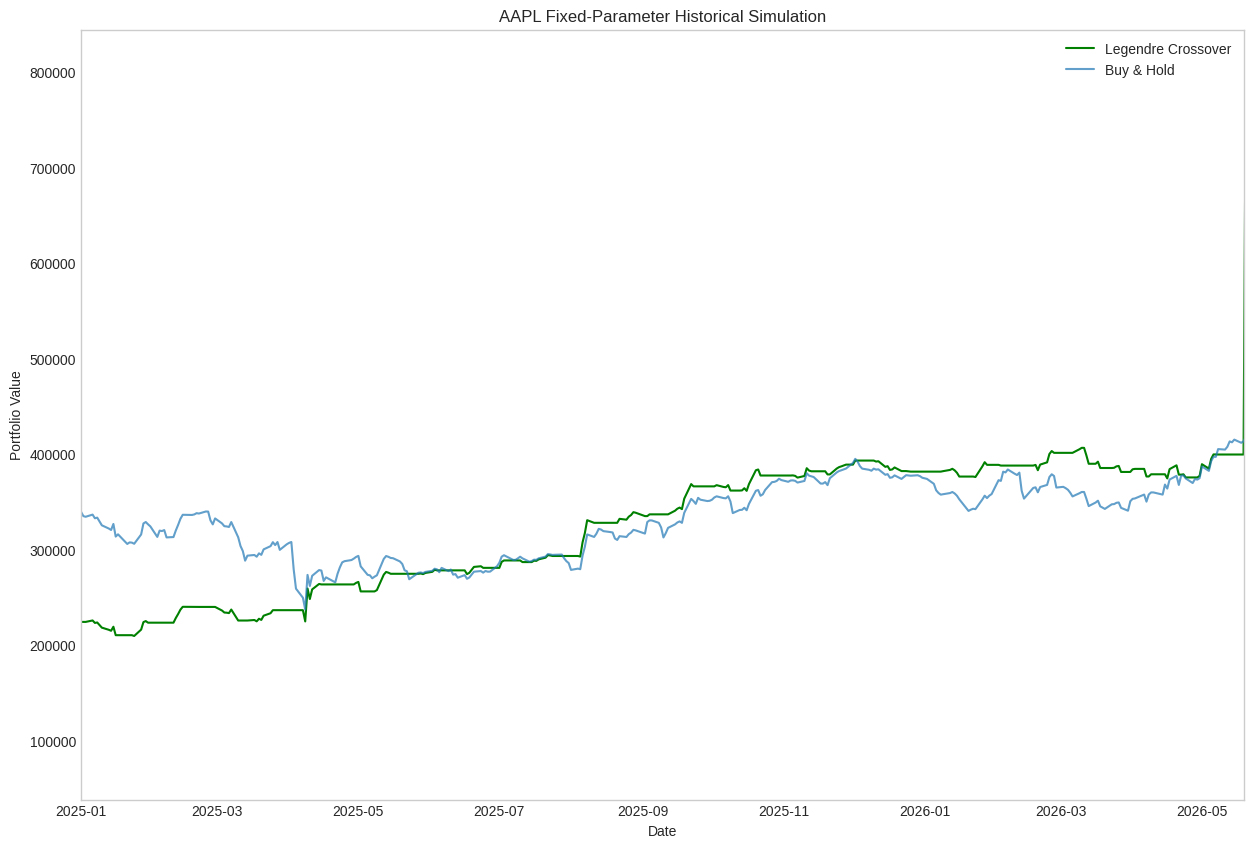

In [15]:
# --- Fixed Parameters ---
window_fast = 5
window_slow = 22
deg = 3
starting_cash = 100000

# --- Causal Legendre Trend Function ---
def causal_legendre(prices, window, deg):
    n = len(prices)
    trend = np.full(n, np.nan)
    for i in range(window-1, n):
        y_win = prices[i-window+1:i+1]
        x_win = np.linspace(-1, 1, window)
        coeffs = legfit(x_win, y_win, deg)
        trend[i] = legval(1, coeffs)  # evaluate at current time
    return trend

# --- Compute trends ---
trend_fast = causal_legendre(prices, window_fast, deg)
trend_slow = causal_legendre(prices, window_slow, deg)

# --- Generate crossover signals ---
signal = np.zeros(n)
for i in range(1, n):
    if np.isnan(trend_fast[i-1]) or np.isnan(trend_slow[i-1]):
        continue
    if trend_fast[i-1] < trend_slow[i-1] and trend_fast[i] > trend_slow[i]:
        signal[i] = 1  # buy
    elif trend_fast[i-1] > trend_slow[i-1] and trend_fast[i] < trend_slow[i]:
        signal[i] = -1  # sell

# --- Backtest causal strategy ---
position = 0
cash = starting_cash
equity = np.zeros(n)
shares = 0

for i in range(n):
    price = prices[i]
    if signal[i] == 1 and position == 0:
        shares = cash // price
        cash -= shares * price
        position = 1
    elif signal[i] == -1 and position == 1:
        cash += shares * price
        shares = 0
        position = 0
    equity[i] = cash + shares * price

# Close final open position
if position == 1:
    equity[-1] += shares * prices[-1]

# --- Buy & Hold Equity ---
buy_hold_equity = starting_cash / prices[0] * prices
dates = data.index

# --- Compute Performance Metrics ---
def compute_metrics(equity, prices, signals):
    returns = np.diff(equity)/equity[:-1]
    total_return = (equity[-1]/equity[0] - 1) * 100
    running_max = np.maximum.accumulate(equity)
    max_drawdown = np.max((running_max - equity)/running_max) * 100
    days = (dates[-1] - dates[0]).days
    years = days / 365.25
    cagr = (equity[-1]/equity[0])**(1/years) - 1
    sharpe = np.mean(returns)/np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0

    # Trades and win rate
    buy_idx = np.where(signals == 1)[0]
    sell_idx = np.where(signals == -1)[0]
    if len(buy_idx) > len(sell_idx):
        sell_idx = np.append(sell_idx, len(equity)-1)
    paired_buys = []
    paired_sells = []
    j = 0
    for b in buy_idx:
        while j < len(sell_idx) and sell_idx[j] < b:
            j += 1
        if j < len(sell_idx):
            paired_buys.append(b)
            paired_sells.append(sell_idx[j])
            j += 1
    paired_buys = np.array(paired_buys, dtype=int)
    paired_sells = np.array(paired_sells, dtype=int)
    trade_profits = prices[paired_sells] - prices[paired_buys]
    total_trades = len(trade_profits)
    win_rate = np.sum(trade_profits > 0)/total_trades*100 if total_trades > 0 else 0

    return total_return, cagr, max_drawdown, sharpe, total_trades, win_rate

# --- Strategy Metrics ---
crossover_metrics = compute_metrics(equity, prices, signal)
buyhold_metrics = compute_metrics(buy_hold_equity, prices, np.zeros(n))

print("=== Causal Legendre Crossover ===")
print(f"Total Return: {crossover_metrics[0]:.1f}%")
print(f"CAGR: {crossover_metrics[1]*100:.1f}%")
print(f"Max Drawdown: {crossover_metrics[2]:.1f}%")
print(f"Sharpe Ratio: {crossover_metrics[3]:.2f}")
print(f"Total Trades: {crossover_metrics[4]}")
print(f"Win Rate: {crossover_metrics[5]:.1f}%")

print("\n=== Buy & Hold ===")
print(f"Total Return: {buyhold_metrics[0]:.1f}%")
print(f"CAGR: {buyhold_metrics[1]*100:.1f}%")
print(f"Max Drawdown: {buyhold_metrics[2]:.1f}%")
print(f"Sharpe Ratio: {buyhold_metrics[3]:.2f}")
print(f"Total Trades: {buyhold_metrics[4]}")
print(f"Win Rate: {buyhold_metrics[5]:.1f}%")

# --- Plot Equity Curves ---
plt.figure(figsize=(15, 10))
plt.plot(dates, equity, label="Legendre Crossover", color="green")
plt.plot(dates, buy_hold_equity, label="Buy & Hold", alpha=0.7)
plt.title(f"{ticker} Fixed-Parameter Historical Simulation")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2026-05-19"))
plt.legend()
plt.grid()
plt.show()

#### **In-Sample Grid Search and Out-of-Sample Backtesting**

In [16]:
# For example, 80% training, 20% testing
split_idx = int(len(prices) * 0.8)

# Training (in-sample)
prices_train = prices[:split_idx]
dates_train = dates[:split_idx]

# Testing (out-of-sample)
prices_test = prices[split_idx:]
dates_test = dates[split_idx:]

In [17]:
# Compute causal trends on test set
trend_fast_test = causal_legendre(prices_test, window_fast, deg)
trend_slow_test = causal_legendre(prices_test, window_slow, deg)

# Generate signals on test set
signal_test = np.zeros(len(prices_test))
for i in range(1, len(prices_test)):
    if np.isnan(trend_fast_test[i-1]) or np.isnan(trend_slow_test[i-1]):
        continue
    if trend_fast_test[i-1] < trend_slow_test[i-1] and trend_fast_test[i] > trend_slow_test[i]:
        signal_test[i] = 1
    elif trend_fast_test[i-1] > trend_slow_test[i-1] and trend_fast_test[i] < trend_slow_test[i]:
        signal_test[i] = -1

# Backtest on test set
position = 0
cash = 100000
equity_test = np.zeros(len(prices_test))
shares = 0

for i in range(len(prices_test)):
    price = prices_test[i]
    if signal_test[i] == 1 and position == 0:
        shares = cash // price
        cash -= shares * price
        position = 1
    elif signal_test[i] == -1 and position == 1:
        cash += shares * price
        shares = 0
        position = 0
    equity_test[i] = cash + shares * price

# Close last open position
if position == 1:
  equity_test[-1] += shares * prices_test[-1]

def compute_metrics(equity, prices, signals, dates):
  # Daily returns
  returns = np.diff(equity) / equity[:-1]

  # Total Return (%)
  total_return = (equity[-1] / equity[0] - 1) * 100

  # Max Drawdown (%)
  running_max = np.maximum.accumulate(equity)
  max_drawdown = np.max((running_max - equity) / running_max) * 100

  # CAGR
  days = (dates[-1] - dates[0]).days
  years = days / 365.25
  cagr = (equity[-1] / equity[0])**(1/years) - 1

  # Sharpe Ratio (annualized)
  sharpe = np.mean(returns) / np.std(returns) * np.sqrt(252) if np.std(returns) > 0 else 0

  # Total Trades and Win Rate
  buy_idx = np.where(signals == 1)[0]
  sell_idx = np.where(signals == -1)[0]

  # Close last open trade
  if len(buy_idx) > len(sell_idx):
    sell_idx = np.append(sell_idx, len(equity)-1)

  # Pair buys with next sell
  paired_buys = []
  paired_sells = []
  j = 0
  for b in buy_idx:
    while j < len(sell_idx) and sell_idx[j] < b:
      j += 1
    if j < len(sell_idx):
      paired_buys.append(b)
      paired_sells.append(sell_idx[j])
      j += 1

  paired_buys = np.array(paired_buys, dtype=int)
  paired_sells = np.array(paired_sells, dtype=int)

  trade_profits = prices[paired_sells] - prices[paired_buys]
  total_trades = len(trade_profits)
  win_rate = np.sum(trade_profits > 0) / total_trades * 100 if total_trades > 0 else 0

  return total_return, cagr, max_drawdown, sharpe, total_trades, win_rate

# --- Compute metrics on test data ---
test_metrics = compute_metrics(equity_test, prices_test, signal_test, dates_test)

print("=== Out-of-Sample Test Metrics ===")
print(f"Total Return: {test_metrics[0]:.1f}%")
print(f"CAGR: {test_metrics[1]*100:.1f}%")
print(f"Max Drawdown: {test_metrics[2]:.1f}%")
print(f"Sharpe Ratio: {test_metrics[3]:.2f}")
print(f"Total Trades: {test_metrics[4]}")
print(f"Win Rate: {test_metrics[5]:.1f}%")

=== Out-of-Sample Test Metrics ===
Total Return: 257.5%
CAGR: 172.6%
Max Drawdown: 7.9%
Sharpe Ratio: 1.38
Total Trades: 35
Win Rate: 60.0%


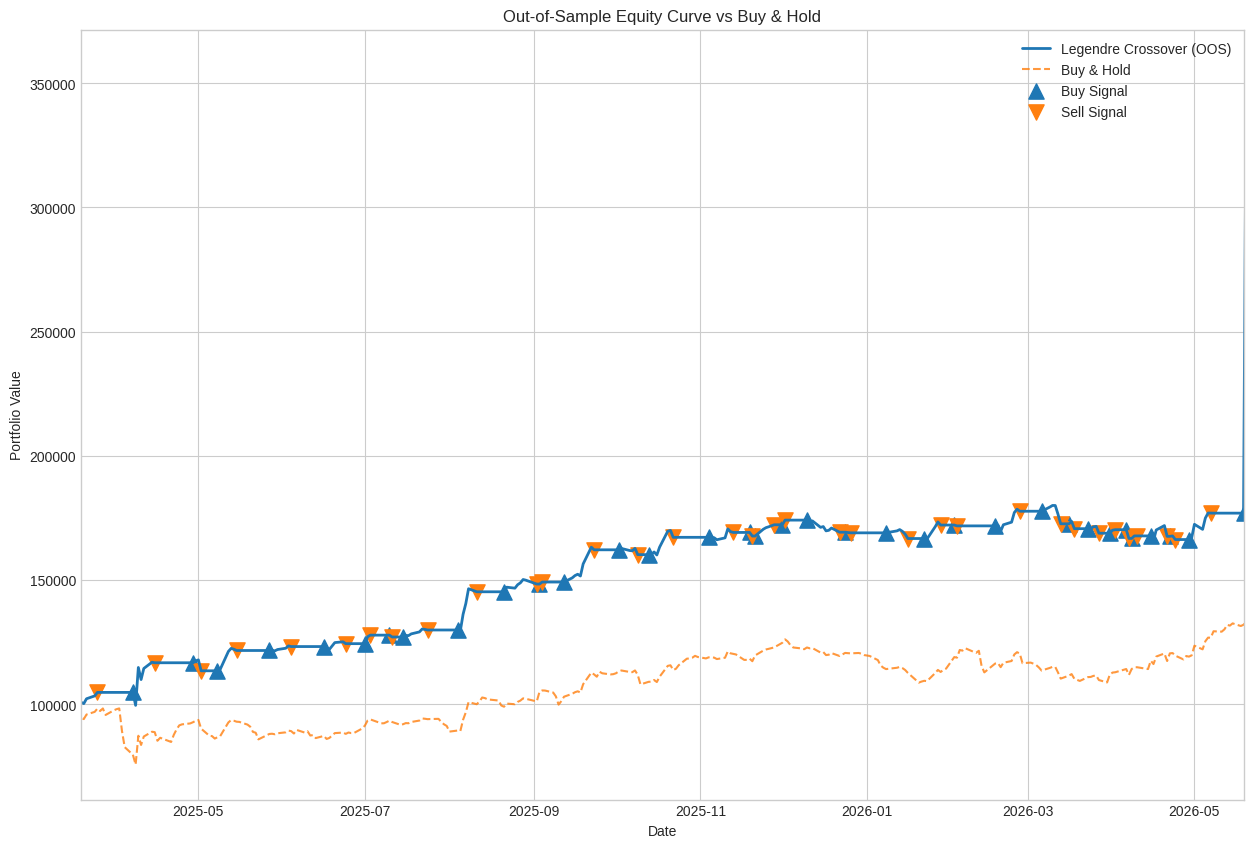

In [18]:
# --- Buy & Hold Equity on Test Set ---
buy_hold_test = 100000 / prices_test[0] * prices_test

# --- Buy/Sell indices ---
buy_idx = np.where(signal_test == 1)[0]
sell_idx = np.where(signal_test == -1)[0]

# --- Plot ---
plt.figure(figsize=(15, 10))

# Strategy equity
plt.plot(
  dates_test,
  equity_test,
  label="Legendre Crossover (OOS)",
  linewidth=2
)

# Buy & Hold
plt.plot(
  dates_test,
  buy_hold_test,
  label="Buy & Hold",
  linestyle="--",
  alpha=0.8
)

# --- Mark BUY trades ---
plt.scatter(
  dates_test[buy_idx],
  equity_test[buy_idx],
  marker="^",
  s=120,
  label="Buy Signal"
)

# --- Mark SELL trades ---
plt.scatter(
  dates_test[sell_idx],
  equity_test[sell_idx],
  marker="v",
  s=120,
  label="Sell Signal"
)

# --- Formatting ---
plt.title("Out-of-Sample Equity Curve vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.xlim(pd.Timestamp("2025-03-19"), pd.Timestamp("2026-05-19"))
plt.grid(True)

plt.show()

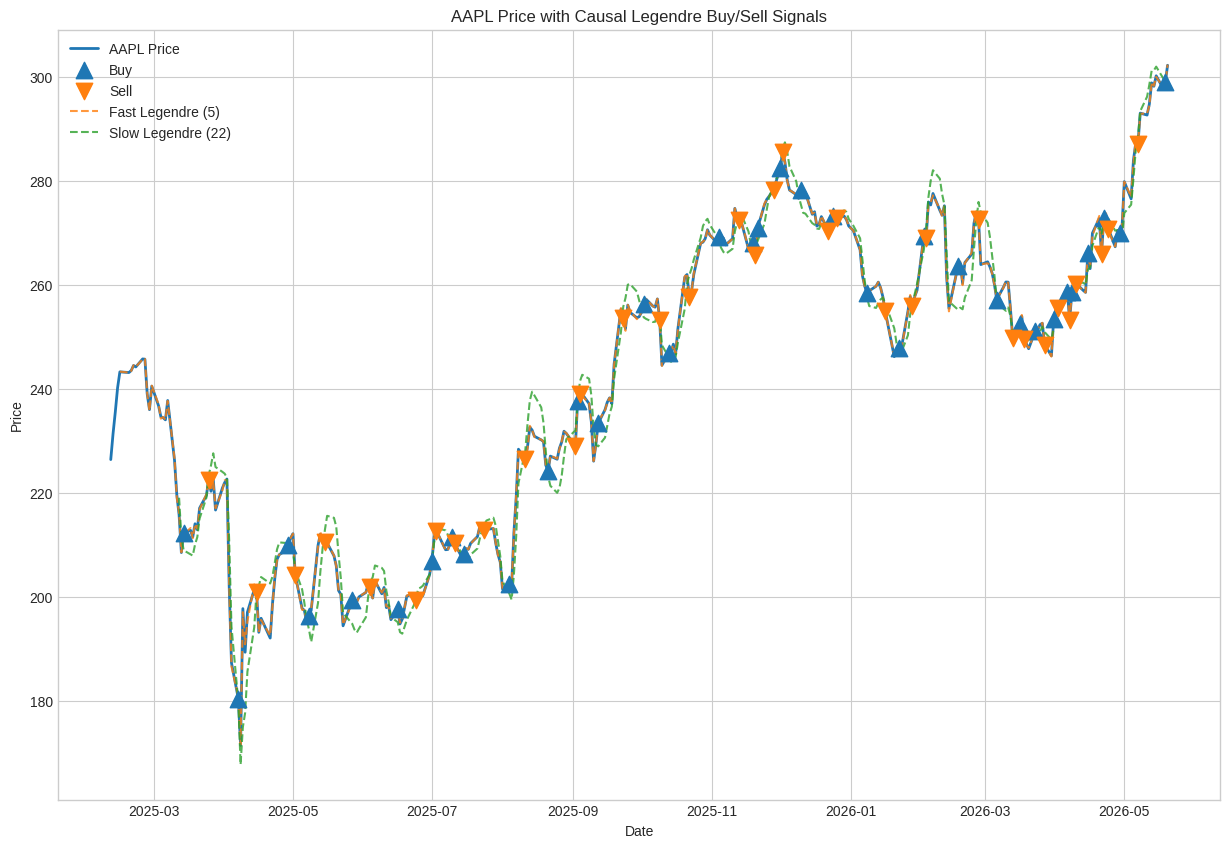

In [19]:
plt.figure(figsize=(15,10))

# Price curve
plt.plot(
  dates_test,
  prices_test,
  label="AAPL Price",
  linewidth=2
)

# Buy markers
buy_idx = np.where(signal_test == 1)[0]

plt.scatter(
    dates_test[buy_idx],
    prices_test[buy_idx],
    marker="^",
    s=140,
    label="Buy",
    zorder=5
)

# Sell markers
sell_idx = np.where(signal_test == -1)[0]

plt.scatter(
  dates_test[sell_idx],
  prices_test[sell_idx],
  marker="v",
  s=140,
  label="Sell",
  zorder=5
)

# Optional: overlay Legendre trends
plt.plot(
  dates_test,
  trend_fast_test,
  linestyle="--",
  alpha=0.8,
  label=f"Fast Legendre ({window_fast})"
)

plt.plot(
  dates_test,
  trend_slow_test,
  linestyle="--",
  alpha=0.8,
  label=f"Slow Legendre ({window_slow})"
)

# Formatting
plt.title("AAPL Price with Causal Legendre Buy/Sell Signals")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

plt.show()

#### **Causal Time-Series Trend Estimation and Multi-Horizon Forecasting Model**

In [20]:
def causal_legendre_forecast(prices, window, deg, horizon):
  n = len(prices)

  forecast = np.full(n, np.nan)

  # rolling normalized coordinates
  x_win = np.linspace(-1, 1, window)

  # future extrapolation coordinate
  x_future = 1 + 2 * horizon / (window - 1)

  for i in range(window - 1, n):
    y_win = prices[i-window+1:i+1]

    coeffs = legfit(x_win, y_win, deg)

    # extrapolated forecast
    forecast[i] = legval(x_future, coeffs)

  return forecast

In [21]:
# 1 step ahead
forecast_1 = causal_legendre_forecast(
  prices_test,
  window_fast,
  deg,
  horizon=1
)

# 3 steps ahead
forecast_3 = causal_legendre_forecast(
  prices_test,
  window_fast,
  deg,
  horizon=3
)

# 5 steps ahead
forecast_5 = causal_legendre_forecast(
  prices_test,
  window_fast,
  deg,
  horizon=5
)

# 10 steps ahead
forecast_10 = causal_legendre_forecast(
  prices_test,
  window_fast,
  deg,
  horizon=10
)

In [22]:
# 5 steps ahead

signal_5 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  if np.isnan(forecast_5[i]):
    continue

  # bullish forecast
  if forecast_5[i] > prices_test[i]:
    signal_5[i] = 1

  # bearish forecast
  elif forecast_5[i] < prices_test[i]:
    signal_5[i] = -1

cash = 100000
position = 0
shares = 0

equity_5 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  price = prices_test[i]

  if signal_5[i] == 1 and position == 0:
    shares = cash // price
    cash -= shares * price
    position = 1

  elif signal_5[i] == -1 and position == 1:
    cash += shares * price
    shares = 0
    position = 0

  equity_5[i] = cash + shares * price

cash = 100000
position = 0
shares = 0

# 1 step ahead

signal_1 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  if np.isnan(forecast_1[i]):
    continue

  # bullish forecast
  if forecast_1[i] > prices_test[i]:
    signal_1[i] = 1

  # bearish forecast
  elif forecast_1[i] < prices_test[i]:
    signal_1[i] = -1

equity_1 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  price = prices_test[i]

  if signal_1[i] == 1 and position == 0:
    shares = cash // price
    cash -= shares * price
    position = 1

  elif signal_1[i] == -1 and position == 1:
    cash += shares * price
    shares = 0
    position = 0

  equity_1[i] = cash + shares * price

#3 steps ahead

signal_3 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  if np.isnan(forecast_3[i]):
    continue

  # bullish forecast
  if forecast_3[i] > prices_test[i]:
    signal_3[i] = 1

  # bearish forecast
  elif forecast_3[i] < prices_test[i]:
    signal_3[i] = -1

equity_3 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  price = prices_test[i]

  if signal_3[i] == 1 and position == 0:
    shares = cash // price
    cash -= shares * price
    position = 1

  elif signal_3[i] == -1 and position == 1:
    cash += shares * price
    shares = 0
    position = 0

  equity_3[i] = cash + shares * price

# 10 steps ahead

signal_10 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
    if np.isnan(forecast_10[i]):
      continue

    # bullish forecast
    if forecast_10[i] > prices_test[i]:
      signal_10[i] = 1

    # bearish forecast
    elif forecast_10[i] < prices_test[i]:
      signal_10[i] = -1

cash = 100000
position = 0
shares = 0

equity_10 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  price = prices_test[i]

  if signal_10[i] == 1 and position == 0:
    shares = cash // price
    cash -= shares * price
    position = 1

  elif signal_10[i] == -1 and position == 1:
    cash += shares * price
    shares = 0
    position = 0

  equity_10[i] = cash + shares * price

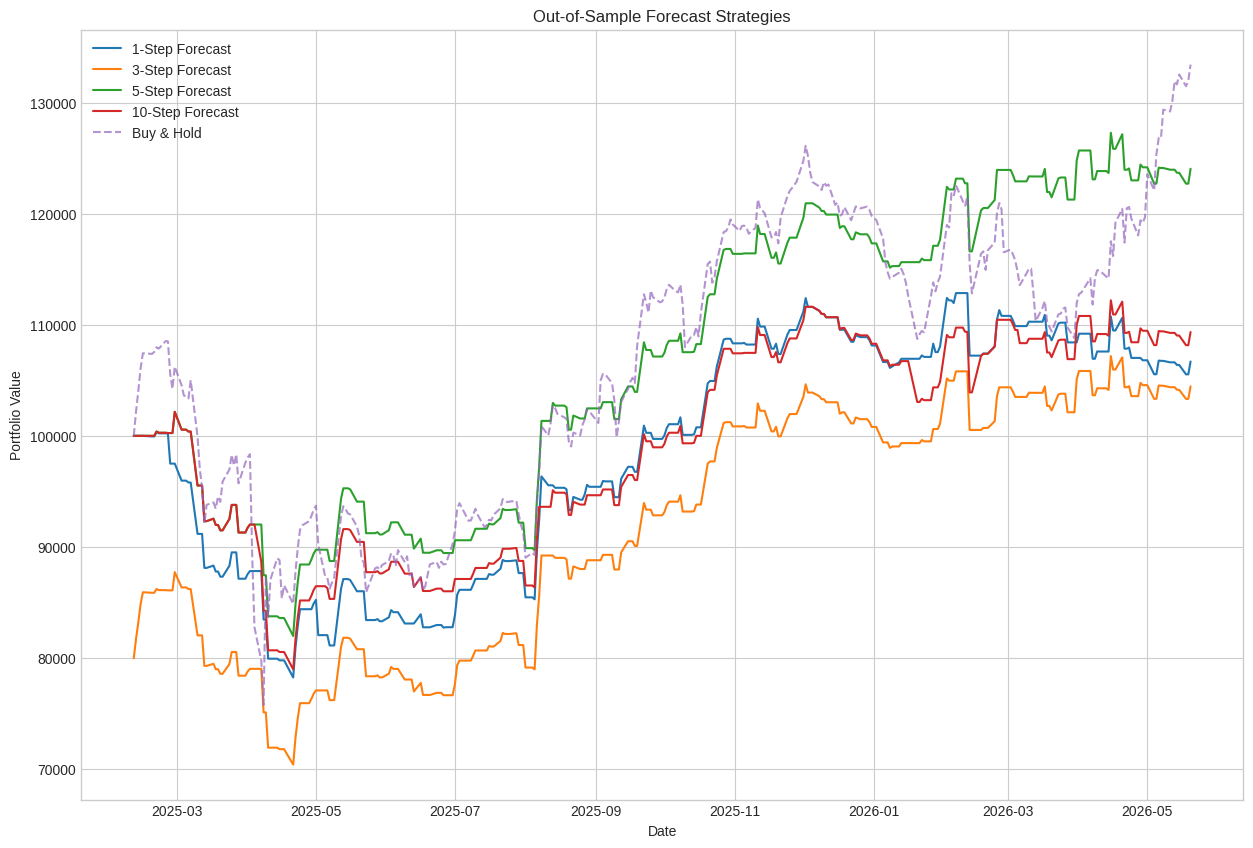

In [23]:
plt.figure(figsize=(15,10))

plt.plot(
  dates_test,
  equity_1,
  label="1-Step Forecast"
)

plt.plot(
  dates_test,
  equity_3,
  label="3-Step Forecast"
)

plt.plot(
  dates_test,
  equity_5,
  label="5-Step Forecast"
)

plt.plot(
  dates_test,
  equity_10,
  label="10-Step Forecast"
)

plt.plot(
  dates_test,
  buy_hold_test,
  linestyle="--",
  alpha=0.7,
  label="Buy & Hold"
)

plt.title("Out-of-Sample Forecast Strategies")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)

plt.show()

In [24]:
# ============================================================
# 5-STEP FORECAST BACKTEST METRICS
# ============================================================

# --- Build 5-step forecast signals ---
signal_5 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  if np.isnan(forecast_5[i]):
    continue

  # bullish forecast
  if forecast_5[i] > prices_test[i]:
    signal_5[i] = 1

  # bearish forecast
  elif forecast_5[i] < prices_test[i]:
    signal_5[i] = -1

# ============================================================
# BACKTEST
# ============================================================

starting_cash = 100000

cash = starting_cash
position = 0
shares = 0

equity_5 = np.zeros(len(prices_test))

for i in range(len(prices_test)):
  price = prices_test[i]

  # BUY
  if signal_5[i] == 1 and position == 0:
    shares = cash // price
    cash -= shares * price
    position = 1

  # SELL
  elif signal_5[i] == -1 and position == 1:
    cash += shares * price
    shares = 0
    position = 0

  equity_5[i] = cash + shares * price

# Close final open position
if position == 1:
  cash += shares * prices_test[-1]
  shares = 0

  equity_5[-1] = cash

# ============================================================
# BUY & HOLD
# ============================================================

buy_hold_test = (
  starting_cash / prices_test[0]
) * prices_test

# ============================================================
# METRICS FUNCTION
# ============================================================

def compute_metrics(
    equity,
    prices,
    signals,
    dates
):

    # -------------------------
    # RETURNS
    # -------------------------

    returns = np.diff(equity) / equity[:-1]

    # -------------------------
    # TOTAL RETURN
    # -------------------------

    total_return = (
        equity[-1] / equity[0] - 1
    ) * 100

    # -------------------------
    # CAGR
    # -------------------------

    days = (
        dates[-1] - dates[0]
    ).days

    years = days / 365.25

    cagr = (
        equity[-1] / equity[0]
    )**(1 / years) - 1

    # -------------------------
    # MAX DRAWDOWN
    # -------------------------

    running_max = np.maximum.accumulate(equity)

    drawdown = (
      running_max - equity
    ) / running_max

    max_drawdown = np.max(drawdown) * 100

    # -------------------------
    # SHARPE RATIO
    # -------------------------

    sharpe = (
      np.mean(returns)
      /
      np.std(returns)
    ) * np.sqrt(252)

    # =====================================================
    # TRADE ANALYSIS
    # =====================================================

    buy_idx = np.where(signals == 1)[0]
    sell_idx = np.where(signals == -1)[0]

    # close open trade
    if len(buy_idx) > len(sell_idx):
      sell_idx = np.append(
        sell_idx,
        len(prices) - 1
      )

    paired_buys = []
    paired_sells = []

    j = 0

    for b in buy_idx:
      while (
        j < len(sell_idx)
        and
        sell_idx[j] < b
      ):
        j += 1

      if j < len(sell_idx):
        paired_buys.append(b)
        paired_sells.append(sell_idx[j])

        j += 1

    paired_buys = np.array(
      paired_buys,
      dtype=int
    )

    paired_sells = np.array(
      paired_sells,
      dtype=int
    )

    trade_profits = (
      prices[paired_sells]
      -
      prices[paired_buys]
    )

    total_trades = len(trade_profits)

    win_rate = (
      np.sum(trade_profits > 0)
      /
      total_trades
      * 100
    ) if total_trades > 0 else 0

    return {
        "Total Return (%)": total_return,
        "CAGR (%)": cagr * 100,
        "Max Drawdown (%)": max_drawdown,
        "Sharpe Ratio": sharpe,
        "Total Trades": total_trades,
        "Win Rate (%)": win_rate
    }

# ============================================================
# COMPUTE METRICS
# ============================================================

metrics_5 = compute_metrics(
  equity_5,
  prices_test,
  signal_5,
  dates_test
)

metrics_bh = compute_metrics(
  buy_hold_test,
  prices_test,
  np.zeros(len(prices_test)),
  dates_test
)

# ============================================================
# PRINT RESULTS
# ============================================================

print("\n=== 5-Step Forecast Strategy ===\n")

for k, v in metrics_5.items():
  if isinstance(v, float):
    print(f"{k}: {v:.2f}")
  else:
    print(f"{k}: {v}")

print("\n=== Buy & Hold ===\n")

for k, v in metrics_bh.items():
  if isinstance(v, float):
    print(f"{k}: {v:.2f}")
  else:
    print(f"{k}: {v}")


=== 5-Step Forecast Strategy ===

Total Return (%): 24.08
CAGR (%): 18.51
Max Drawdown (%): 19.78
Sharpe Ratio: 1.01
Total Trades: 145
Win Rate (%): 54.48

=== Buy & Hold ===

Total Return (%): 33.47
CAGR (%): 25.52
Max Drawdown (%): 30.22
Sharpe Ratio: 0.90
Total Trades: 0
Win Rate (%): 0
